In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
jahnavipaliwal_customer_feedback_and_satisfaction_path = kagglehub.dataset_download('jahnavipaliwal/customer-feedback-and-satisfaction')

print('Data source import complete.')


Data source import complete.


# Customer Feedback and Satisfaction Analysis

This notebook demonstrates how to analyze customer feedback and satisfaction using a synthetic dataset. We will load the dataset, explore it, and build a Random Forest model to predict customer satisfaction.

## Step 1: Install Required Libraries

```python
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Load the dataset
df = pd.read_csv(r'E:\Unified_Mentor_Projects\Customer-satisfaction-prediction\customer_feedback_satisfaction.csv')
df.head(5)

,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,Male,UK,83094,5,8,5,Low,Bronze,100.0
1,2,69,Male,UK,86860,10,2,8,Medium,Gold,100.0
2,3,46,Female,USA,60173,8,10,18,Medium,Silver,100.0
3,4,32,Female,UK,73884,7,10,16,Low,Gold,100.0
4,5,60,Male,UK,97546,6,4,13,Low,Bronze,82.0


In [4]:
# Check the shape of the dataset
print(f"Dataset Shape: {df.shape}")

# Display basic info
df.info()

# Display summary statistics
df.describe()


Dataset Shape: (38444, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB


,CustomerID,Age,Income,ProductQuality,ServiceQuality,PurchaseFrequency,SatisfactionScore
count,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000
mean,19222.500000,43.496853,75076.619238,5.494746,5.492769,10.453881,85.276409
std,11097.971211,14.972748,25975.752966,2.873192,2.875812,5.765621,16.898577
min,1.000000,18.000000,30001.000000,1.000000,1.000000,1.000000,4.280000
25%,9611.750000,31.000000,52624.500000,3.000000,3.000000,5.000000,74.470000
50%,19222.500000,43.000000,75236.000000,5.000000,5.000000,10.000000,91.270000
75%,28833.250000,56.000000,97606.750000,8.000000,8.000000,15.000000,100.000000
max,38444.000000,69.000000,119999.000000,10.000000,10.000000,20.000000,100.000000


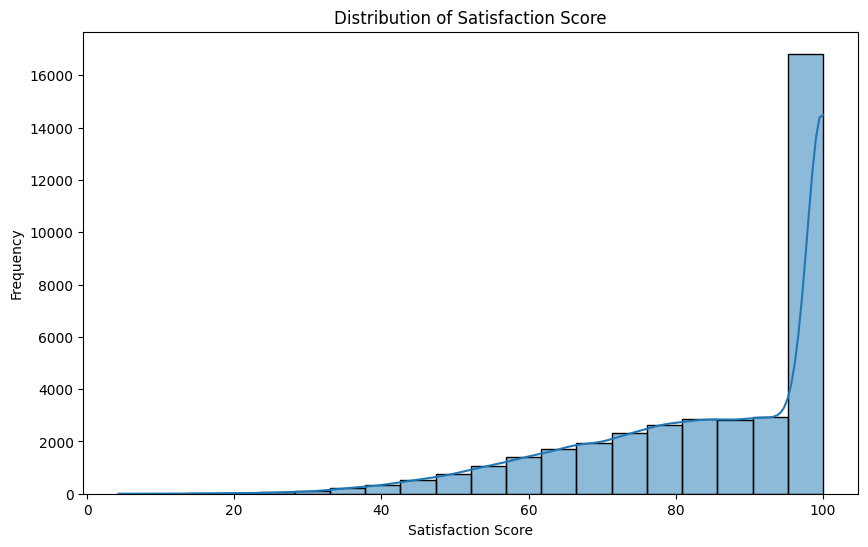

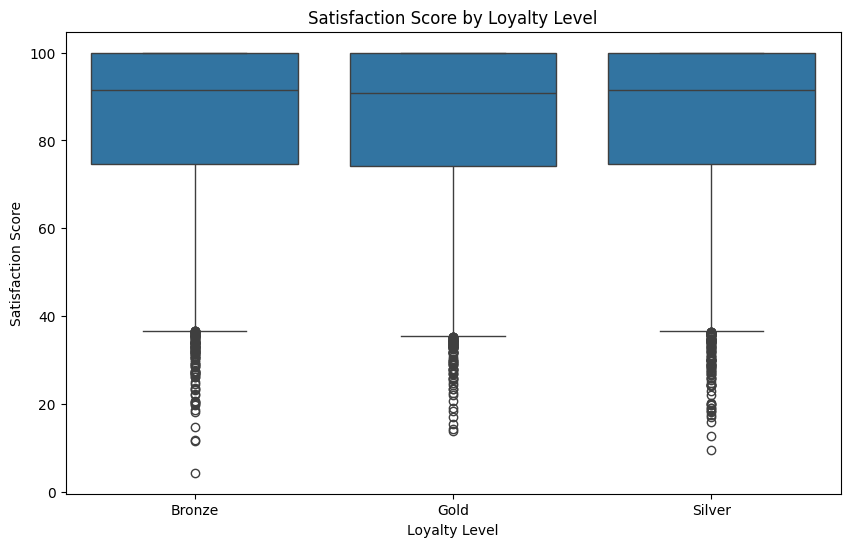

In [5]:
# Distribution of Satisfaction Score
plt.figure(figsize=(10, 6))
sns.histplot(df['SatisfactionScore'], bins=20, kde=True)
plt.title('Distribution of Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.show()

# Boxplot of Satisfaction Score by Loyalty Level
plt.figure(figsize=(10, 6))
sns.boxplot(x='LoyaltyLevel', y='SatisfactionScore', data=df)
plt.title('Satisfaction Score by Loyalty Level')
plt.xlabel('Loyalty Level')
plt.ylabel('Satisfaction Score')
plt.show()


In [6]:
# Encode categorical features
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Country'] = le.fit_transform(df['Country'])
df['FeedbackScore'] = le.fit_transform(df['FeedbackScore'])
df['LoyaltyLevel'] = le.fit_transform(df['LoyaltyLevel'])

# Define features and target variable
X = df.drop(columns=['CustomerID', 'SatisfactionScore'])
y = df['SatisfactionScore']


In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [9]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 65.74
R² Score: 0.77
